In [436]:
# Importação das bibliotecas pandas e numpy para manipulação e análise de dados
import pandas as pd
import numpy as np

# Análise de Dados de Obesidade
Este notebook irá analisar dados de obesidade em diferentes países ao longo dos anos

In [437]:
# Carregamento do dataset de obesidade a partir do arquivo CSV
df_obesity = pd.read_csv(r'data/obesity_cleaned.csv')
df_obesity.head()

,Unnamed: 0,Country,Year,Obesity (%),Sex
0,0,Afghanistan,1975,0.5 [0.2-1.1],Both sexes
1,1,Afghanistan,1975,0.2 [0.0-0.6],Male
2,2,Afghanistan,1975,0.8 [0.2-2.0],Female
3,3,Afghanistan,1976,0.5 [0.2-1.1],Both sexes
4,4,Afghanistan,1976,0.2 [0.0-0.7],Male


In [438]:
# Verificação da estrutura do dataset: tipos de dados, valores não nulos e uso de memória
df_obesity.info()

<class 'pandas.DataFrame'>
RangeIndex: 24570 entries, 0 to 24569
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   24570 non-null  int64
 1   Country      24570 non-null  str  
 2   Year         24570 non-null  int64
 3   Obesity (%)  24570 non-null  str  
 4   Sex          24570 non-null  str  
dtypes: int64(2), str(3)
memory usage: 959.9 KB


In [439]:
# Análise da coluna 'Unnamed: 0' para verificar se contém valores únicos ou repetidos
# Esta verificação ajuda a decidir se a coluna deve ser removida
df_obesity['Unnamed: 0'].value_counts()

Unnamed: 0
0        1
1        1
2        1
3        1
4        1
        ..
24565    1
24566    1
24567    1
24568    1
24569    1
Name: count, Length: 24570, dtype: int64

In [440]:
# Remoção da coluna 'Unnamed: 0' pois parece ser um índice desnecessário
# Parâmetro inplace=True modifica o DataFrame diretamente
df_obesity.drop(columns=['Unnamed: 0'], inplace=True)

In [441]:
# Inspeção da coluna 'Obesity (%)' para entender o formato dos dados
# Observa-se que os valores contêm números e intervalos entre colchetes
df_obesity['Obesity (%)']

0           0.5 [0.2-1.1]
1           0.2 [0.0-0.6]
2           0.8 [0.2-2.0]
3           0.5 [0.2-1.1]
4           0.2 [0.0-0.7]
               ...       
24565       4.5 [2.4-7.6]
24566    24.8 [18.9-31.3]
24567    15.5 [12.0-19.2]
24568       4.7 [2.5-8.0]
24569    25.3 [19.1-32.0]
Name: Obesity (%), Length: 24570, dtype: str

In [442]:
# Extração apenas do valor numérico da coluna 'Obesity (%)'
# Usa split para separar pelo espaço e pega apenas a primeira parte (o valor principal)
df_obesity['Obesity %'] = df_obesity['Obesity (%)'].str.split(' ', expand=True)[0]

In [443]:
# Análise da distribuição dos valores na nova coluna 'Obesity %'
# normalize=True mostra a proporção de cada valor em relação ao total
df_obesity['Obesity %'].value_counts(normalize=True)

Obesity %
No      0.020513
0.4     0.009035
0.6     0.008873
0.5     0.008832
0.7     0.008547
          ...   
54.2    0.000041
55.3    0.000041
48.1    0.000041
42.7    0.000041
46.5    0.000041
Name: proportion, Length: 602, dtype: float64

In [444]:
# Limpeza e conversão dos dados da coluna 'Obesity %':
# 1. Substitui valores 'No' por NaN (valores ausentes)
# 2. Remove valores NaN com dropna()
# 3. Converte a coluna para tipo numérico (float)
# 4. Garante que a coluna 'Year' seja do tipo inteiro
df_obesity.loc[df_obesity['Obesity %'] == 'No', 'Obesity %'] = np.nan
df_obesity['Obesity %'] = df_obesity['Obesity %'].dropna()
df_obesity['Obesity %'] = df_obesity['Obesity %'].astype(float)
df_obesity['Year'] = df_obesity['Year'].astype(int)

In [445]:
# Verificação final da estrutura do DataFrame após as limpezas
# Confirma os tipos de dados e a contagem de valores não nulos
df_obesity.info()

<class 'pandas.DataFrame'>
RangeIndex: 24570 entries, 0 to 24569
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      24570 non-null  str    
 1   Year         24570 non-null  int64  
 2   Obesity (%)  24570 non-null  str    
 3   Sex          24570 non-null  str    
 4   Obesity %    24066 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 959.9 KB


In [446]:
# Define a coluna 'Year' como índice do DataFrame para facilitar análises temporais
# inplace=True modifica o DataFrame diretamente
df_obesity.set_index('Year', inplace=True)

Qual o percentual médio de obesidade por sexo no mundo no ano de 2015?

In [447]:
# Resposta à questão: Filtra dados do ano 2015 e agrupa por sexo para calcular a média
# numeric_only=True garante que apenas colunas numéricas sejam incluídas no cálculo
df_obesity[df_obesity.index == 2015].groupby('Sex').mean(numeric_only=True)

,Obesity %
Sex,
Both sexes,19.508377
Female,22.899476
Male,15.980628


Quais são os 5 países com maior taxa de aumento nos índices de obesidade no período observado?

In [448]:
df_obesity_start = df_obesity[df_obesity.index == 1975]
df_obesity_end = df_obesity[df_obesity.index == 2016]

In [449]:
df_obesity_start.set_index('Country', inplace=True)
df_obesity_end.set_index('Country', inplace=True)

In [450]:
df_obesity_ev = df_obesity_end[df_obesity_end['Sex'] == 'Both sexes']['Obesity %'] - df_obesity_start[df_obesity_start['Sex'] == 'Both sexes']['Obesity %']

In [451]:
df_obesity_ev.sort_values().dropna().head()

Country
Viet Nam       2.0
Singapore      3.1
Japan          3.3
Bangladesh     3.4
Timor-Leste    3.6
Name: Obesity %, dtype: float64

In [452]:
df_obesity_ev.sort_values().dropna().tail()

Country
Cook Islands    27.9
Tonga           28.3
Kiribati        30.1
Niue            31.1
Tuvalu          33.7
Name: Obesity %, dtype: float64

Quais os países com maiores e menores níveis percentuais de obesidade de 2015? 

In [453]:
df_2015 = df_obesity[df_obesity.index == 2015]
df_2015.sort_values(by='Obesity %', ascending=False).head()

,Country,Obesity (%),Sex,Obesity %
Year,,,,
2015,Nauru,63.1 [55.5-70.3],Female,63.1
2015,Nauru,60.7 [55.2-66.1],Both sexes,60.7
2015,Cook Islands,58.8 [51.0-66.3],Female,58.8
2015,Palau,58.4 [49.9-66.4],Female,58.4
2015,Nauru,58.2 [50.5-65.8],Male,58.2


In [454]:
df_2015.sort_values(by='Obesity %').head()

,Country,Obesity (%),Sex,Obesity %
Year,,,,
2015,Viet Nam,1.5 [0.8-2.5],Male,1.5
2015,Uganda,1.7 [0.8-3.1],Male,1.7
2015,Ethiopia,1.8 [0.8-3.4],Male,1.8
2015,Rwanda,1.8 [0.8-3.3],Male,1.8
2015,Eritrea,1.9 [0.9-3.7],Male,1.9


Qual a diferença média percentual de obesidade entre os sexos ao lingo dos anos para o Brasil?

In [455]:
df_brazil = df_obesity[df_obesity['Country'] == 'Brazil']

<Axes: xlabel='Year'>

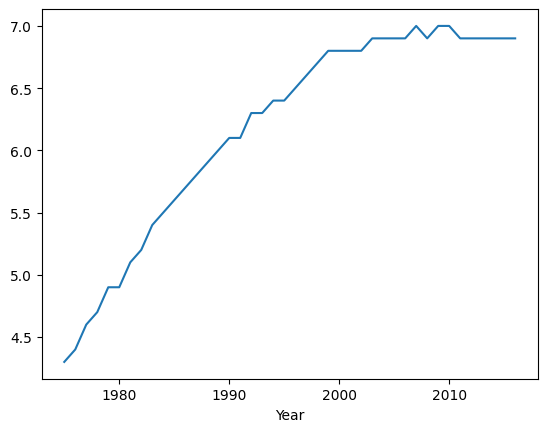

In [456]:
(df_brazil[df_brazil['Sex'] == 'Female']['Obesity %'] - df_brazil[df_brazil['Sex'] == 'Male']['Obesity %']).plot()

Você conseguiria plotar um gráfico mostrando a evolução da obesidade para ambos os sexos no mundo?

In [457]:
df_both = df_obesity[df_obesity['Sex'] == 'Both sexes']

<Axes: xlabel='Year'>

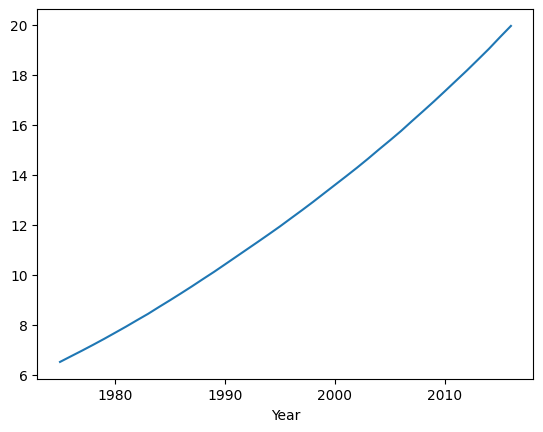

In [458]:
df_both.groupby('Year')['Obesity %'].mean().plot()

# GDP per Person (1901-2011)

In [459]:
df_gdp = pd.read_csv('data/gdp.csv', decimal='.')
df_gdp

,Country,Region,Year,GDP_pp
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1901,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1906,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1911,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1916,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1921,662.40
...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1/1/1991,782.09
4415,Zimbabwe,Sub-Saharan Africa,1/1/1996,781.50
4416,Zimbabwe,Sub-Saharan Africa,1/1/2001,719.96
4417,Zimbabwe,Sub-Saharan Africa,1/1/2006,520.17


In [460]:
df_gdp.info()

<class 'pandas.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Country   4419 non-null   str  
 1   Region    4419 non-null   str  
 2   Year      4419 non-null   str  
 3    GDP_pp   4419 non-null   str  
dtypes: str(4)
memory usage: 138.2 KB


In [461]:
df_gdp['Year'] = pd.to_datetime(df_gdp['Year'], format='%m/%d/%Y').dt.year

In [462]:
df_gdp['Year'].iloc[0]

np.int32(1901)

In [463]:
df_gdp.columns = df_gdp.columns.str.strip()

In [464]:
df_gdp['GDP_pp'].iloc[0]

' 613.99 '

In [465]:
df_gdp['GDP_pp'] = df_gdp['GDP_pp'].str.strip()

In [466]:
df_gdp['GDP_pp'].iloc[0]

'613.99'

In [467]:
df_gdp['GDP_pp'] = df_gdp['GDP_pp'].str.replace(',', '').astype(float)

In [468]:
df_gdp.info()

<class 'pandas.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  4419 non-null   str    
 1   Region   4419 non-null   str    
 2   Year     4419 non-null   int32  
 3   GDP_pp   4419 non-null   float64
dtypes: float64(1), int32(1), str(2)
memory usage: 121.0 KB


Informar o primeiro valor registrado em cada país

In [469]:
df_gdp.sort_values('Year').groupby('Country').agg(
    Year=('Year', 'min'),
    GDP_pp=('GDP_pp', 'first')
)

,Year,GDP_pp
Country,,
Afghanistan,1901,613.99
Albania,1901,1062.01
Algeria,1901,1807.76
Andorra,1901,3352.50
Angola,1901,525.76
...,...,...
Venezuela,1901,766.21
Vietnam,1901,572.96
"Yemen, Rep.",1901,729.39


In [470]:
df_gdp.sort_values('Year').groupby('Country').agg(
    Year=('Year', 'min'),
    GDP_pp=('GDP_pp', 'first')
)['Year'].value_counts()

Year
1901    192
1991      1
Name: count, dtype: int64

In [471]:
df_gdp.sort_values('Year').groupby('Country').agg(
    Year=('Year', 'min'),
    GDP_pp=('GDP_pp', 'first')
)[df_gdp.sort_values('Year').groupby('Country').agg(
    Year=('Year', 'min'),
    GDP_pp=('GDP_pp', 'first')
)['Year'] == 1991]

,Year,GDP_pp
Country,,
Kosovo,1991,5453.79


Regiões com maiores crescimentos de PIB per capita no século passado

In [472]:
df_gdp_start = df_gdp[df_gdp['Year'] == df_gdp['Year'].min()]
df_gdp_end = df_gdp[df_gdp['Year'] == df_gdp[df_gdp['Year'] < 2000]['Year'].max()]

In [473]:
((df_gdp_end.groupby('Region')['GDP_pp'].mean() / df_gdp_start.groupby('Region')['GDP_pp'].mean()) * 100).sort_values(ascending=False)

Region
Middle East, North Africa, and Greater Arabia    957.215950
Asia                                             811.761516
Europe                                           694.046167
North America                                    689.760175
Central America and the Caribbean                506.426789
Australia and Oceania                            496.075383
South America                                    412.123735
Sub-Saharan Africa                               348.633780
Name: GDP_pp, dtype: float64

Preencha os anos ausentes em cada país com uma estimativa, baseando na diferença entre o próximo registro e o anterior.

In [474]:
all_years = pd.RangeIndex(df_gdp['Year'].min(), df_gdp['Year'].max())
missing_years = all_years.difference(df_gdp['Year'])

df_years_off = pd.DataFrame({'Year': missing_years})
df_years_off

,Year
0,1902
1,1903
2,1904
3,1905
4,1907
...,...
83,2005
84,2007
85,2008
86,2009


In [475]:
df_gdp = df_gdp.sort_values(by=['Country', 'Year'])

df_gdp['delta_gdp'] = df_gdp.groupby('Country')['GDP_pp'].diff()
df_gdp['delta_year'] = df_gdp.groupby('Country')['Year'].diff()
df_gdp['gdp_year'] = (df_gdp['delta_gdp'] / df_gdp['delta_year']).shift(-1)
df_gdp.head()

,Country,Region,Year,GDP_pp,delta_gdp,delta_year,gdp_year
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901,613.99,NaN,NaN,2.010
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906,624.04,10.05,5.0,2.042
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911,634.25,10.21,5.0,2.606
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916,647.28,13.03,5.0,3.024
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921,662.40,15.12,5.0,3.094


In [476]:
df_gdp['next_year'] = df_gdp['Year'].shift(-1)
del df_gdp['delta_gdp'], df_gdp['delta_year']

In [477]:
df_gdp.head()

,Country,Region,Year,GDP_pp,gdp_year,next_year
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901,613.99,2.010,1906.0
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906,624.04,2.042,1911.0
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911,634.25,2.606,1916.0
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916,647.28,3.024,1921.0
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921,662.40,3.094,1926.0


In [478]:
df_gdp.info()

<class 'pandas.DataFrame'>
RangeIndex: 4419 entries, 0 to 4418
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    4419 non-null   str    
 1   Region     4419 non-null   str    
 2   Year       4419 non-null   int32  
 3   GDP_pp     4419 non-null   float64
 4   gdp_year   4226 non-null   float64
 5   next_year  4418 non-null   float64
dtypes: float64(3), int32(1), str(2)
memory usage: 190.0 KB


In [479]:
new_data = pd.DataFrame()

for idx, row in df_gdp.iterrows():
    if row['Year'] == df_gdp['Year'].max():
        continue

    years_to_add = df_years_off[(df_years_off['Year'] < row['next_year']) & (df_years_off['Year'] > row['Year'])]
    
    for new_year in years_to_add['Year']:
        add_row = row.copy()
        add_row['GDP_pp'] = (new_year - add_row['Year']) * add_row['gdp_year'] + add_row['GDP_pp']
        add_row['Year'] = new_year
        add_row['kind'] = 'estimated'
        new_data = pd.concat([new_data, add_row.to_frame().T])
        

In [480]:
new_data.head()

,Country,Region,Year,GDP_pp,gdp_year,next_year,kind
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1902,616.0,2.01,1906.0,estimated
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1903,618.01,2.01,1906.0,estimated
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1904,620.02,2.01,1906.0,estimated
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1905,622.03,2.01,1906.0,estimated
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1907,626.082,2.042,1911.0,estimated


In [481]:
df_gdp = pd.concat([df_gdp, new_data])
df_gdp.sort_values(['Country', 'Year'], inplace=True)
df_gdp.set_index('Year', inplace=True)
df_gdp.fillna({'kind': 'real'}, inplace=True)


,Country,Region,GDP_pp,gdp_year,next_year,kind
Year,,,,,,
1901,Afghanistan,"Middle East, North Africa, and Greater Arabia",613.99,2.01,1906.0,real
1902,Afghanistan,"Middle East, North Africa, and Greater Arabia",616.0,2.01,1906.0,estimated
1903,Afghanistan,"Middle East, North Africa, and Greater Arabia",618.01,2.01,1906.0,estimated
1904,Afghanistan,"Middle East, North Africa, and Greater Arabia",620.02,2.01,1906.0,estimated
1905,Afghanistan,"Middle East, North Africa, and Greater Arabia",622.03,2.01,1906.0,estimated
...,...,...,...,...,...,...
2007,Zimbabwe,Sub-Saharan Africa,521.402,1.232,2011.0,estimated
2008,Zimbabwe,Sub-Saharan Africa,522.634,1.232,2011.0,estimated
2009,Zimbabwe,Sub-Saharan Africa,523.866,1.232,2011.0,estimated


In [484]:
df_gdp.sample(15)

,Country,Region,GDP_pp,gdp_year,next_year,kind
Year,,,,,,
1940,Greece,Europe,3113.252,-176.632,1941.0,estimated
1949,Mauritania,Sub-Saharan Africa,709.15,6.96,1951.0,estimated
1958,France,Europe,9546.45,380.07,1961.0,estimated
2003,Indonesia,Asia,3018.09,115.28,2006.0,estimated
1998,Haiti,Central America and the Caribbean,1319.166,-5.132,2001.0,estimated
1996,Cape Verde,Sub-Saharan Africa,1788.78,123.558,2001.0,real
1922,Niger,Sub-Saharan Africa,608.766,4.056,1926.0,estimated
1903,Nepal,Asia,529.98,3.78,1906.0,estimated
1928,Philippines,Asia,1462.22,-0.74,1931.0,estimated


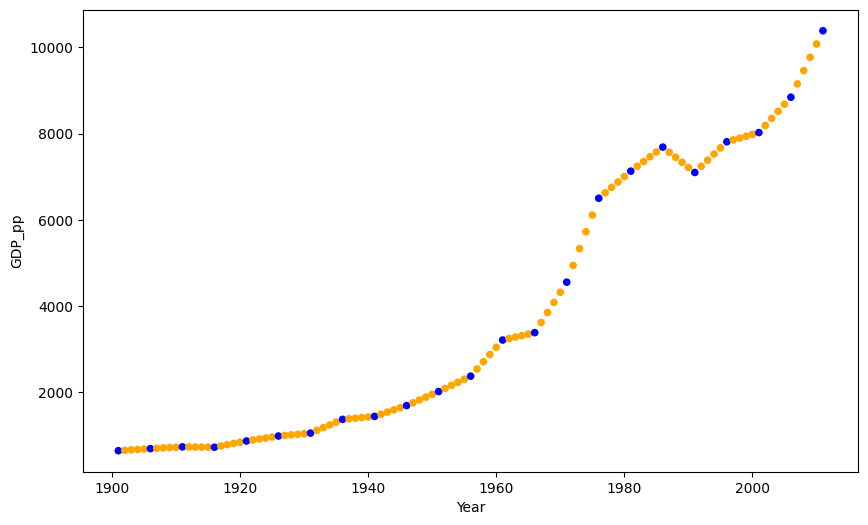

In [494]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

country = 'Brazil'
df_plot = df_gdp[(df_gdp['kind'].isin(['real', 'estimated'])) & (df_gdp['Country'] == country)].reset_index()
colors = {'real': 'blue', 'estimated': 'orange'}
df_plot.plot(kind='scatter', y='GDP_pp', x='Year', ax=ax, c=df_plot['kind'].map(colors))
plt.show()